# Week 5 – Scenario Analysis

## 5.1 Scenario Design
    
## 5.2 Scenario Calculation
    
## 5.3 Scenario Visualisation
    
## 5.4 Impact Summary
    
## 5.5 Week 5 Conclusion
    
## Introduction
This notebook investigates possible future CO₂ emission pathways under different climate policy scenarios.
Instead of developing a new forecasting model, the ETS(A,Ad,N) forecast generated in Week 4 is used as the baseline projection. Different mitigation strategies are then applied to estimate how policy interventions may influence future emissions between 2025 and 2040.
The scenarios presented in this notebook are illustrative and intended for comparison purposes only. They are not scientifically calibrated climate policy projections.

In [96]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df_features = pd.read_csv(
    "data/ghg_features.csv"
)

forecast_test = pd.read_csv(
    "data/forecast_test.csv"
)

df_features.head()

forecast_test.head()

,country,Year,Forecast_CO2,Lower_95CI,Upper_95CI
0,Australia,2024,416.581363,408.364331,424.798395
1,Australia,2025,418.258674,410.041642,426.475705
2,Australia,2026,419.821343,411.604311,428.038374
3,Australia,2027,421.277205,413.060174,429.494237
4,Australia,2028,422.633562,414.416530,430.850593


In [97]:
scenario_data = forecast_test[
    (forecast_test["Year"]>=2025) &
    (forecast_test["Year"]<=2040)
].copy()
scenario_data.head()

,country,Year,Forecast_CO2,Lower_95CI,Upper_95CI
1,Australia,2025,418.258674,410.041642,426.475705
2,Australia,2026,419.821343,411.604311,428.038374
3,Australia,2027,421.277205,413.060174,429.494237
4,Australia,2028,422.633562,414.416530,430.850593
5,Australia,2029,423.897213,415.680181,432.114244


## Scenario Design
### Scenario A – Business as Usual (BAU): 
No policy change; use the ETS(A,Ad,N) baseline forecast from Week 4
### Scenario B – Moderate Mitigation: 
Apply a linear annual reduction rate of 2% per year to the BAU forecast starting from 2025
### Scenario C – Aggressive Mitigation: 
Apply a linear annual reduction rate of 5% per year to the BAU forecast starting from 2025


## Scenario Calculation

In [98]:
scenario_rows=[]

for country in scenario_data["country"].unique():
    temp=scenario_data[
        scenario_data["country"]==country
    ].sort_values("Year")
    for _,row in temp.iterrows():
        year=row["Year"]
        forecast=row["Forecast_CO2"]
        years_after=year-2025
        bau=forecast
        moderate=max(
            forecast*(1-0.02*years_after),0)
        aggressive=max(
            forecast*(1-0.05*years_after),0)

        scenario_rows.append(
            [country,year,"BAU",bau])

        scenario_rows.append(
            [country,year,"Moderate",moderate])

        scenario_rows.append(
            [country,year,"Aggressive",aggressive])

scenario_df=pd.DataFrame(
    scenario_rows,
    columns=[
        "Country",
        "Year",
        "Scenario",
        "CO2_Projected"
    ]
)
scenario_df.head()

,Country,Year,Scenario,CO2_Projected
0,Australia,2025,BAU,418.258674
1,Australia,2025,Moderate,418.258674
2,Australia,2025,Aggressive,418.258674
3,Australia,2026,BAU,419.821343
4,Australia,2026,Moderate,411.424916


In [99]:
scenario_df.to_csv(
    "data/scenario_projections.csv",
    index=False
)
print("Scenario projections saved.")

Scenario projections saved.


## Scenario Visualisations

The following figures compare historical CO₂ emissions with three future policy scenarios.
Each chart displays:
- Historical emissions
- Business as Usual (BAU)
- Moderate Mitigation
- Aggressive Mitigation
- 1990 emission benchmark

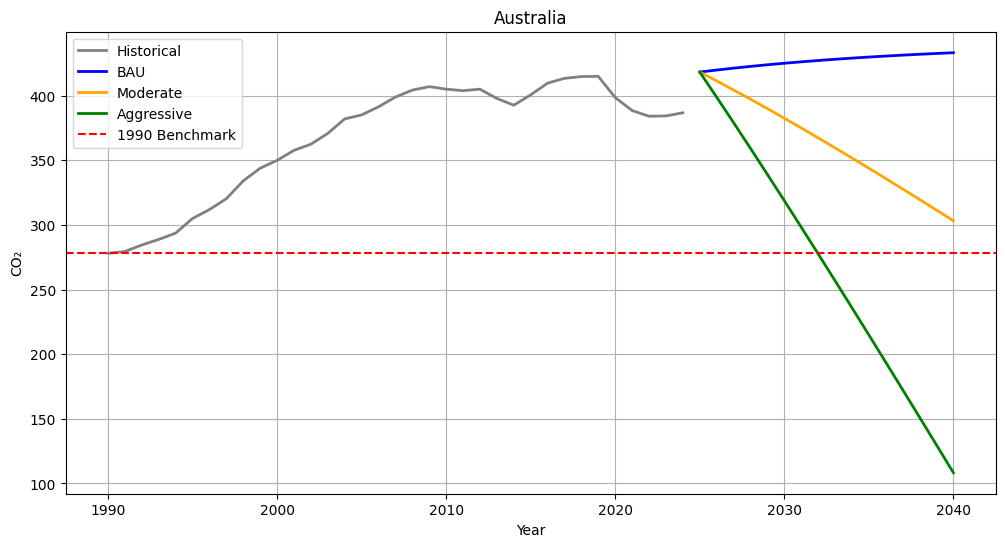

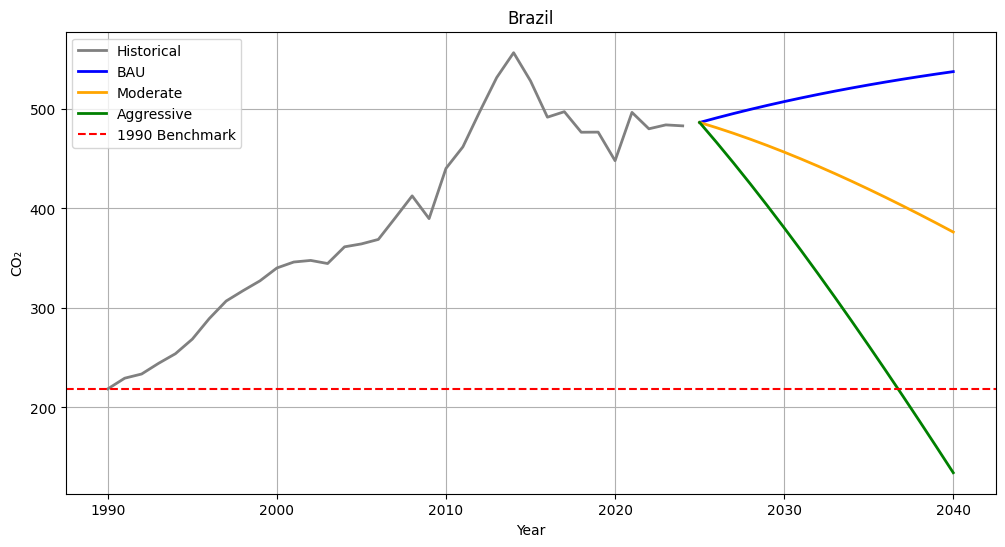

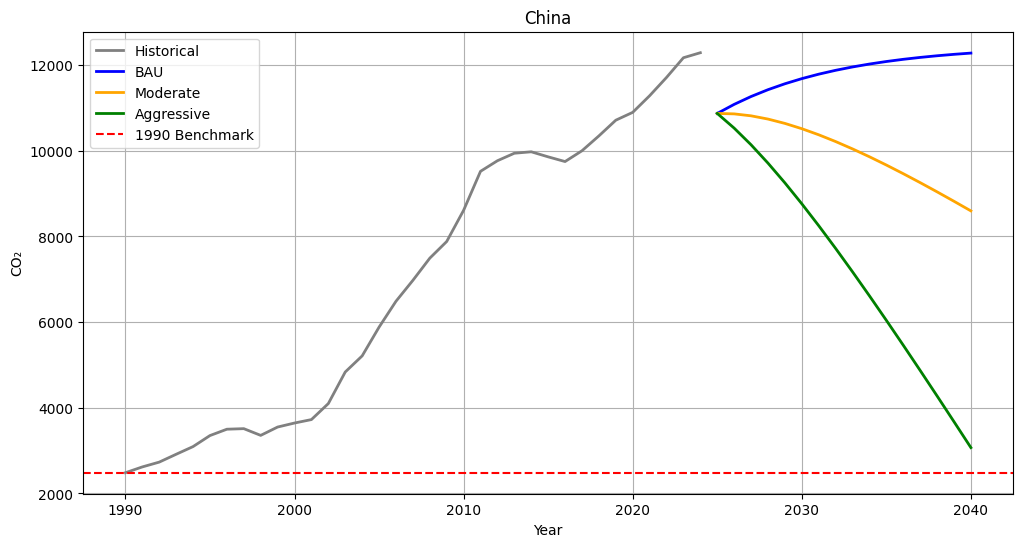

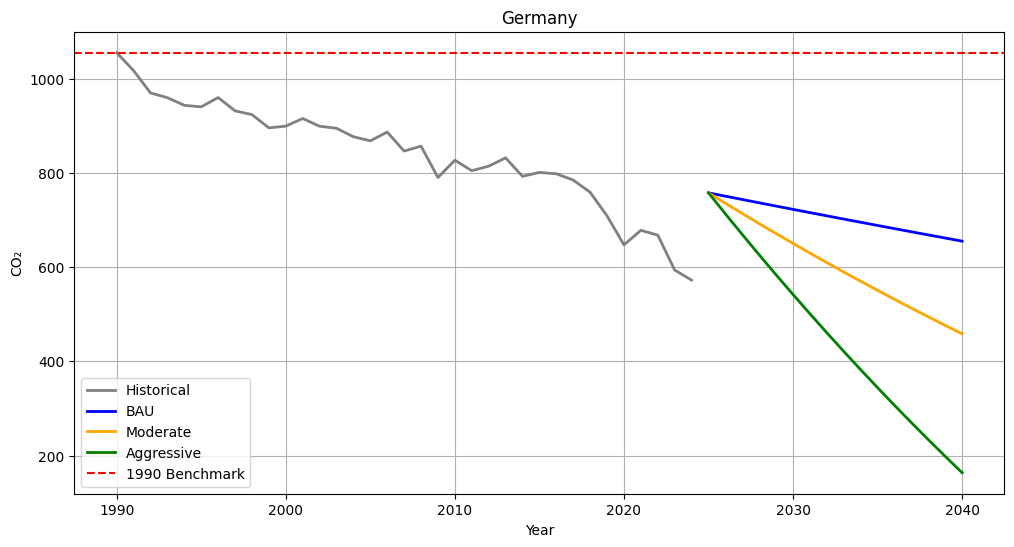

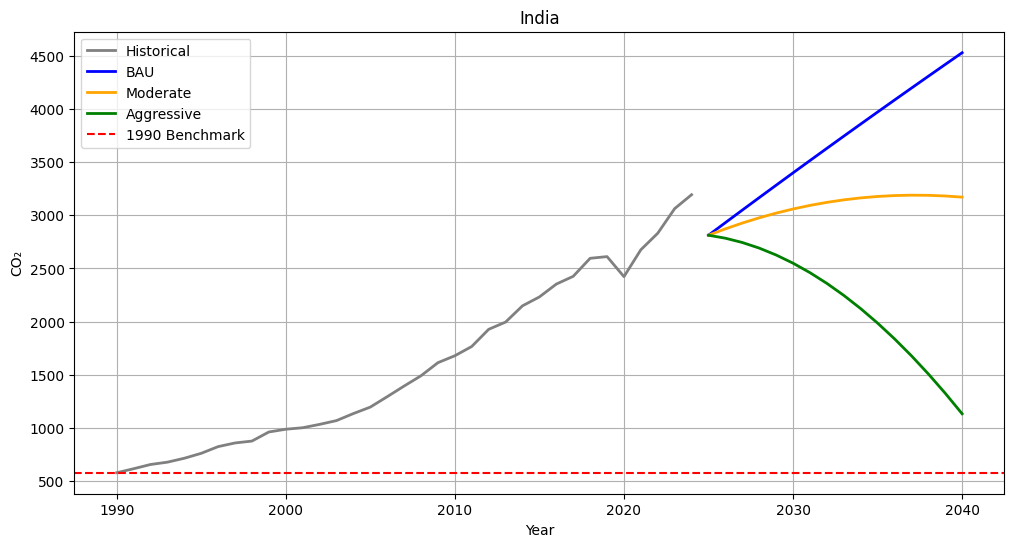

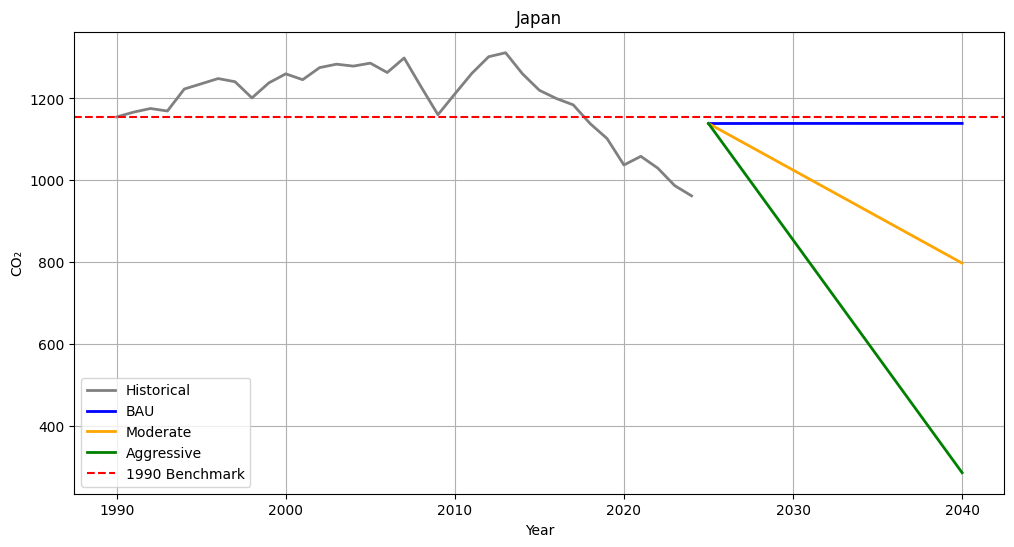

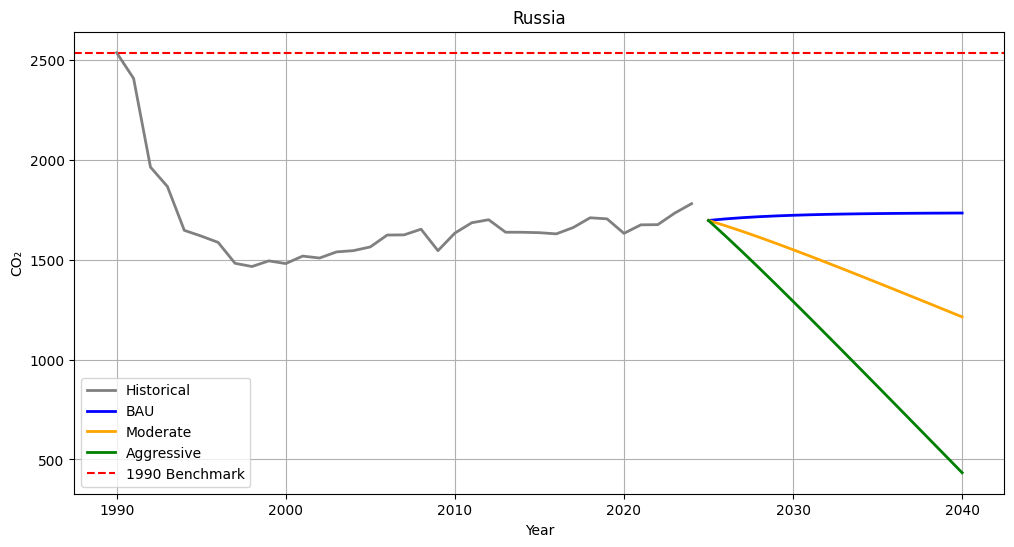

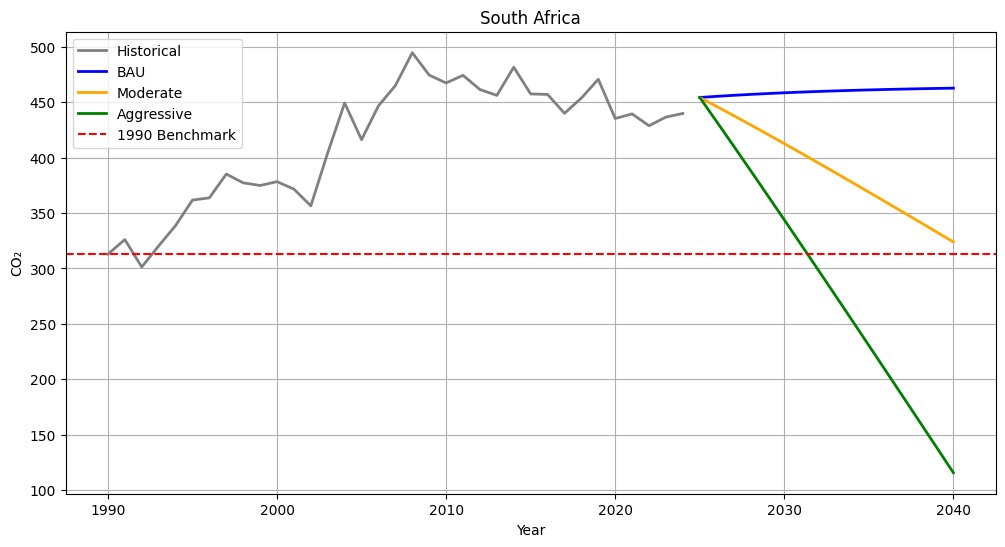

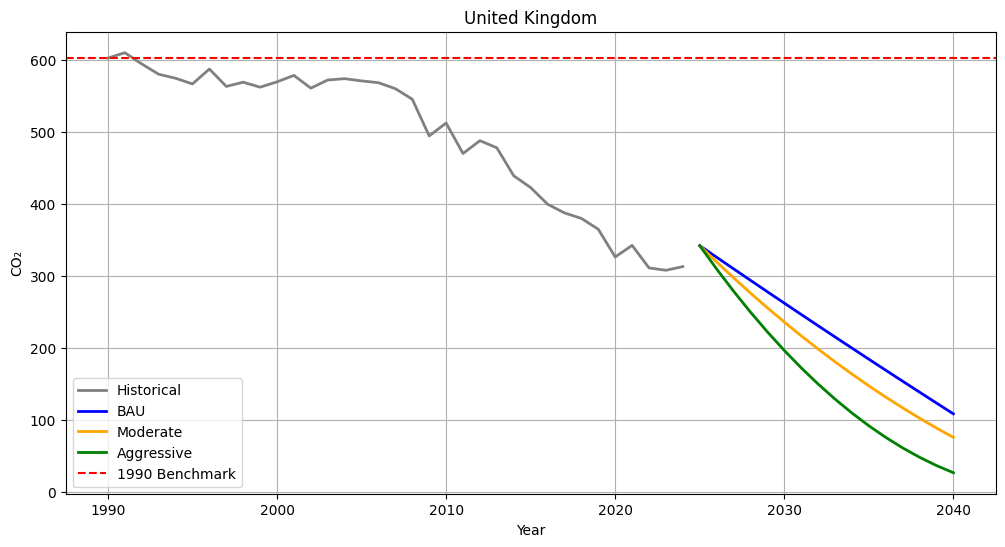

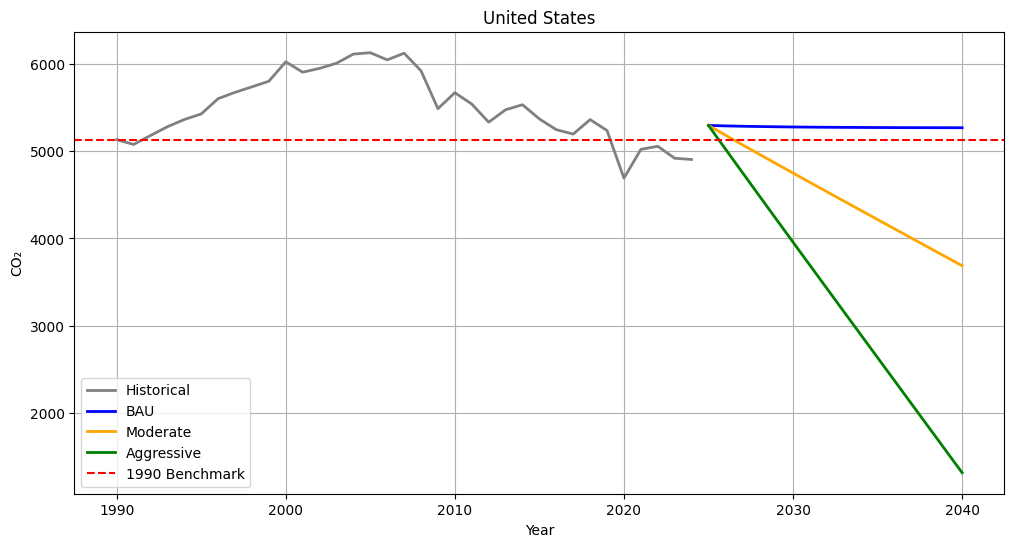

In [100]:
historical=df_features.copy()
colors={
    "BAU":"blue",
    "Moderate":"orange",
    "Aggressive":"green"
}

for country in scenario_df["Country"].unique():
    plt.figure(figsize=(12,6))
    hist=historical[
        historical["country"]==country
    ]
    plt.plot(
        hist["year"],
        hist["co2"],
        color="grey",
        linewidth=2,
        label="Historical"
    )
    for scenario in colors:
        temp=scenario_df[
            (scenario_df["Country"]==country)&
            (scenario_df["Scenario"]==scenario)
        ]

        plt.plot(
            temp["Year"],
            temp["CO2_Projected"],
            color=colors[scenario],
            linewidth=2,
            label=scenario
        )

    benchmark=hist[
        hist["year"]==1990
    ]["co2"].iloc[0]
    plt.axhline(
        benchmark,
        color="red",
        linestyle="--",
        label="1990 Benchmark"
    )
    plt.title(country)
    plt.xlabel("Year")
    plt.ylabel("CO₂")
    plt.legend()
    plt.grid(True)
    plt.show()

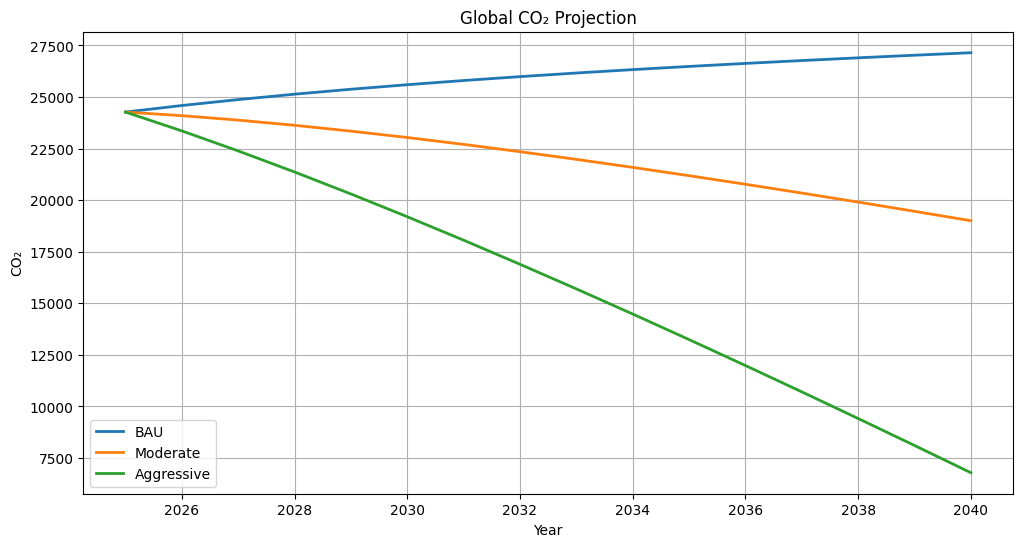

In [101]:
global_projection=(
    scenario_df.groupby(
        ["Year","Scenario"])["CO2_Projected"].sum().reset_index()
)
plt.figure(figsize=(12,6))
for scenario in colors:
    temp=global_projection[
        global_projection["Scenario"]==scenario
    ]
    plt.plot(
        temp["Year"],
        temp["CO2_Projected"],
        linewidth=2,
        label=scenario
    )
plt.title(
    "Global CO₂ Projection"
)
plt.xlabel("Year")
plt.ylabel("CO₂")
plt.grid(True)
plt.legend()
plt.show()

## Impact Summary

To compare the long-term environmental impact of each policy scenario, cumulative CO₂ emissions from 2025 to 2040 are calculated for every country.

In [102]:
impact_summary=(
    scenario_df.groupby(["Country","Scenario"])["CO2_Projected"].sum().reset_index()
)
impact_summary.rename(
    columns={
        "CO2_Projected":"Cumulative_CO2"
    },
    inplace=True
)
impact_summary.head()

,Country,Scenario,Cumulative_CO2
0,Australia,Aggressive,4252.800696
1,Australia,BAU,6831.202592
2,Australia,Moderate,5799.841834
3,Brazil,Aggressive,5088.814184
4,Brazil,BAU,8234.244672


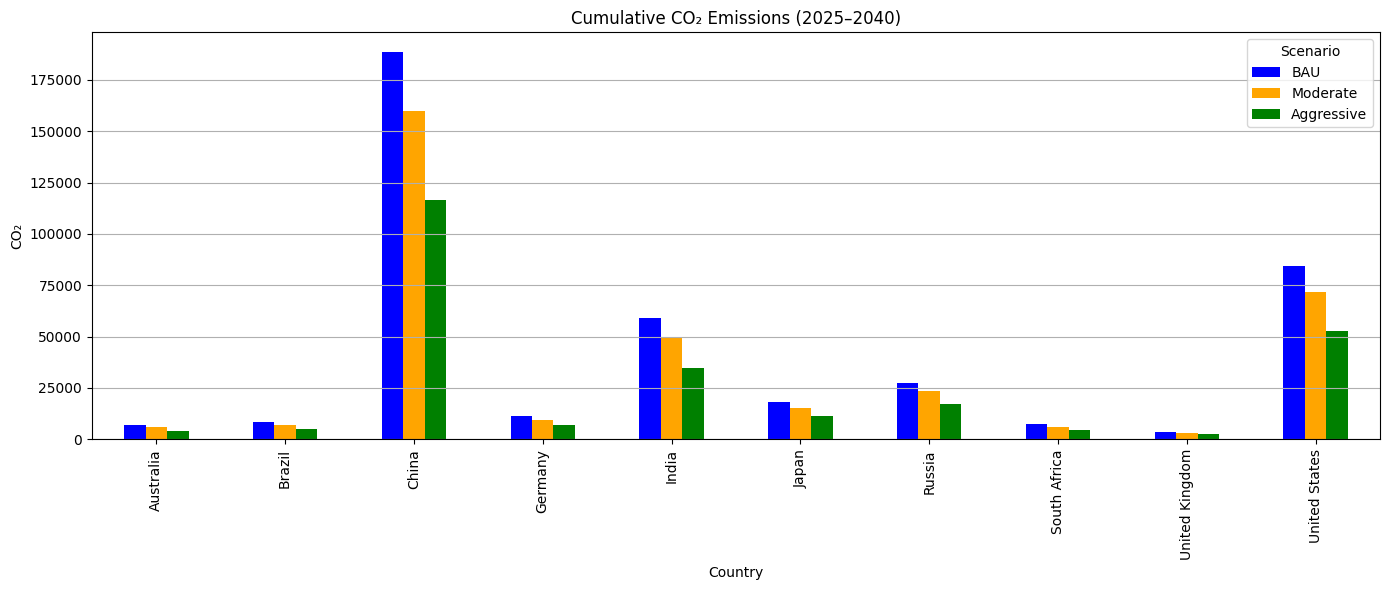

In [103]:
pivot=impact_summary.pivot(
    index="Country",
    columns="Scenario",
    values="Cumulative_CO2"
)
pivot=pivot[
    ["BAU","Moderate","Aggressive"]
]

pivot.plot(
    kind="bar",
    figsize=(14,6),
    color=["blue","orange","green"]
)
plt.title("Cumulative CO₂ Emissions (2025–2040)")
plt.ylabel("CO₂")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

In [104]:
scenario_projections =  pd.read_csv("data/scenario_projections.csv")
scenario_projections.head()

,Country,Year,Scenario,CO2_Projected
0,Australia,2025,BAU,418.258674
1,Australia,2025,Moderate,418.258674
2,Australia,2025,Aggressive,418.258674
3,Australia,2026,BAU,419.821343
4,Australia,2026,Moderate,411.424916


In [105]:
scenario_impact_summary =  pd.read_csv("data/scenario_impact_summary.csv")
scenario_impact_summary.head()

,Country,Scenario,Cumulative_CO2
0,Australia,Aggressive,4252.800696
1,Australia,BAU,6831.202592
2,Australia,Moderate,5799.841834
3,Brazil,Aggressive,5088.814184
4,Brazil,BAU,8234.244672


## Interpretation

The Business as Usual scenario produces the highest cumulative CO₂ emissions because no mitigation measures are introduced.
The Moderate Mitigation scenario gradually lowers cumulative emissions through a 2% annual reduction beginning in 2025.
The Aggressive Mitigation scenario achieves the largest reduction in emissions across all countries.
Countries with relatively large baseline emissions, including China, India, and the United States, experience the greatest absolute reductions under the Aggressive Mitigation scenario.
These results illustrate the potential long-term benefits of stronger emission reduction policies.

In [106]:
impact_summary.to_csv(
    "data/scenario_impact_summary.csv",
    index=False
)
print("Impact summary saved.")

Impact summary saved.


## Week 5 Summary

In this notebook, scenario analysis was performed using the ETS(A,Ad,N) forecast developed in Week 4.
Three policy scenarios—Business as Usual, Moderate Mitigation, and Aggressive Mitigation—were evaluated for all ten countries between 2025 and 2040.
The scenario projections, country-level comparisons, global trends, and cumulative emission analysis demonstrated how stronger mitigation strategies could substantially reduce long-term CO₂ emissions.
Although these scenarios are illustrative rather than policy-calibrated, they provide a useful framework for comparing possible future climate policy outcomes.